# Joint sampling of response and response time (`sampling_type="JOINT"`)

With the `TIMESTEP` transition type the model defines a joint distribution over the response $RA \in \{c, w\}$ and the step $n$ at which the first response is emitted:

$$P(RA, n) = \mathbf{1}^\top M_{RA}\, T_\delta \,(M_{none}\, T_\delta)^{\,n-1}\, \phi_0 \qquad (\text{Quantum: } \|M_{RA}\, T_\delta (M_{none} T_\delta)^{n-1} \phi_0\|^2)$$

`joint_response_pmf` evaluates this for every $n = 1 \dots n_{max}$ with a single scan (the same recursion the likelihood uses), and `get_joint_RT_RA` draws $(RA, n)$ pairs from it with a categorical draw per trial. Mass not yet responded by $n_{max}$ is kept as a third outcome and appears in the samples as `RA = NaN`, `RT = NaN`.

Parameters below follow `examples/fit_data.py`: 11 states, response width 1, measurement probability 0.7, $\delta = 1$, so response times are in steps.

In [1]:
import os, sys
os.environ["JAX_PLATFORMS"] = "cpu"
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import jax.numpy as npx
import matplotlib.pyplot as plt

from cme.decision_models import confidence_accumulation as ca

n_states, response_width, measurement_prob, delta = 11, 1, 0.7, 1.0
start_width = 5
max_RT_sec = 50
J = 2000

g++ not available, if using conda: `conda install gxx`


## Parameter grid

`mu` and `sigma` are on the scale of the sampled parameters in `model`. The final diffusion rate that enters `diffusion_buildK` / `quantum_buildH` is derived exactly as `model` does it: $|\mu| + \sigma$ for Markov and $\max(0.5|\mu| + \sigma, 0.01)$ for Quantum. For Markov the constraint $\sigma_{final} \ge |\mu|$ is what keeps the off-diagonal rates $\tfrac12(\sigma_{final} \mp \mu)$ non-negative; without it $\exp(K\delta)$ is not a stochastic matrix and the "probabilities" turn negative, which is the same failure that appears as negative likelihoods during NUTS warmup when `sigma` is sampled below zero.

Each grid cell is treated as one participant so a single call produces all cells.

In [2]:
mus = [0.0, 0.25, 0.5, 1.0]
sigmas = [0.5, 1.0, 2.0]
grid = pd.DataFrame([(m, s) for s in sigmas for m in mus], columns=["mu", "sigma"])
I = len(grid)
drift_rate = npx.asarray(grid["mu"].values)[:, None]
sigma = npx.asarray(grid["sigma"].values)[:, None]

def final_diffusion(model_type):
    if model_type == "Markov":
        return npx.abs(drift_rate) + sigma
    return npx.clip(npx.abs(drift_rate) * 0.5 + sigma, 0.01, None)

grid

,mu,sigma
0,0.00,0.5
1,0.25,0.5
2,0.50,0.5
3,1.00,0.5
4,0.00,1.0
5,0.25,1.0
6,0.50,1.0
7,1.00,1.0
8,0.00,2.0
9,0.25,2.0


In [3]:
def run(model_type, seed=0):
    phi_0 = ca._get_initial_state(n_states, start_width, response_width, I=I, model_type=model_type, prior_type="Centered")
    return ca.get_joint_RT_RA(n_states, response_width, delta, measurement_prob,
                              drift_rate, final_diffusion(model_type), phi_0, data_samples=(I, J),
                              max_RT_sec=max_RT_sec, model_type=model_type, seed=seed)

results = {mt: run(mt) for mt in ["Markov", "Quantum"]}
results["Markov"]["Samples"].head()

,,drift_rate,diffusion_rate,RT,RA,prob,param_sample_id
part_id,pseudo_item_id,,,,,,
0,0,0.00,0.50,23.0,-1.0,0.007167,-1
1,0,0.25,0.75,9.0,-1.0,0.001696,-1
2,0,0.50,1.00,13.0,1.0,0.047512,-1
3,0,1.00,1.50,8.0,1.0,0.083559,-1
4,0,0.00,1.00,15.0,-1.0,0.011641,-1


## Model pmf and drawn samples

Solid lines are $P(c, n)$ (up) and $P(w, n)$ (mirrored down) from the scan. Bars are histograms of the drawn samples, normalised to the same scale, so the bars should trace the lines up to sampling noise.

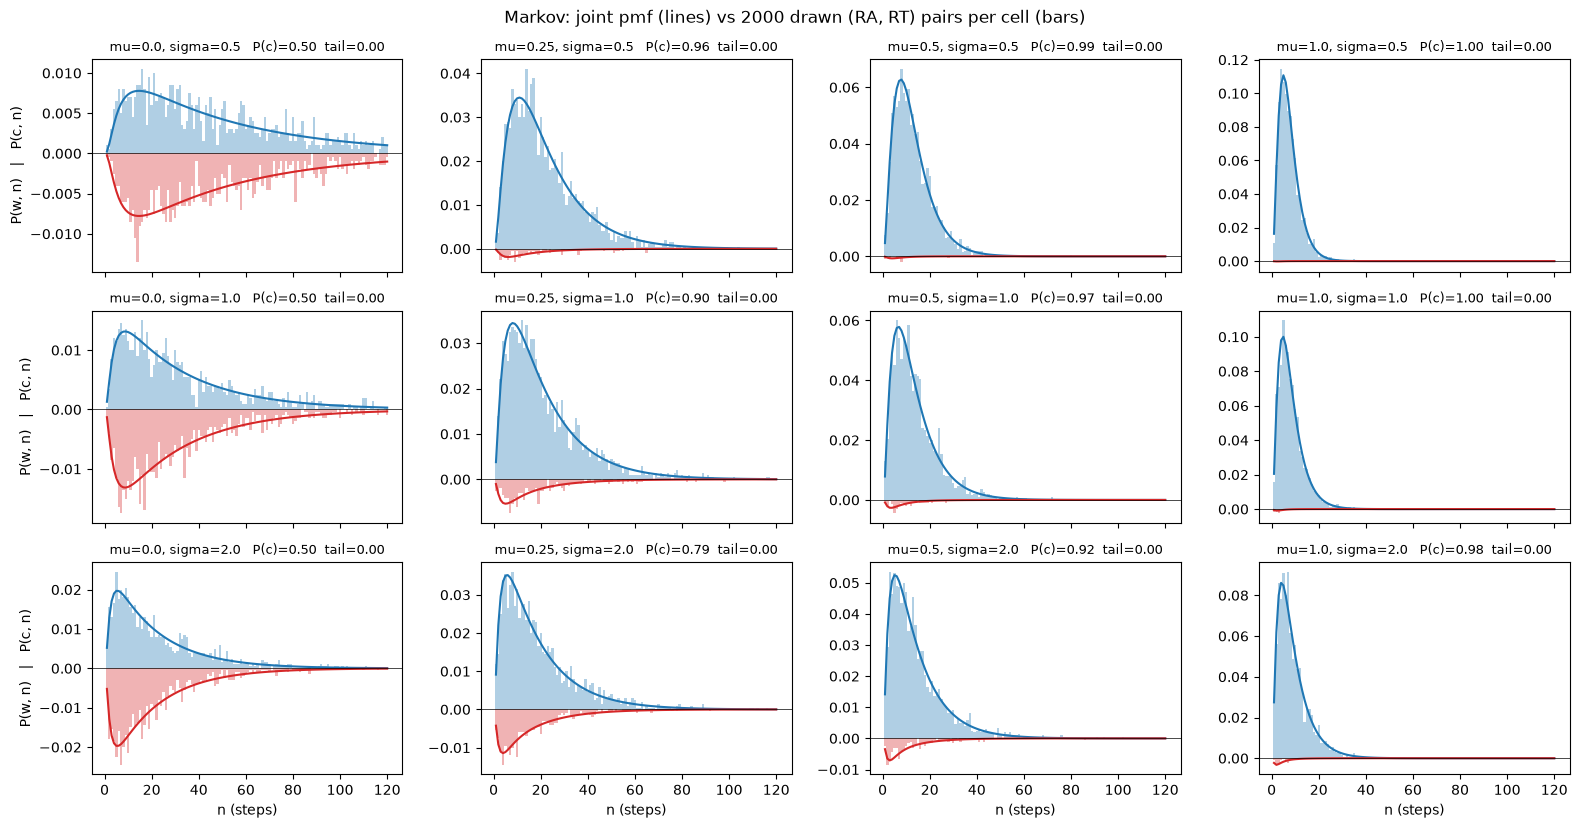

In [4]:
def plot_pmf_and_samples(model_type, n_show=120):
    out = results[model_type]
    pmf, df = out["pmf"], out["Samples"].reset_index()
    n = np.arange(1, pmf.shape[-1] + 1)
    fig, axes = plt.subplots(len(sigmas), len(mus), figsize=(4 * len(mus), 2.8 * len(sigmas)), sharex=True)
    for i, (mu, sigma) in enumerate(grid.itertuples(index=False)):
        ax = axes[sigmas.index(sigma), mus.index(mu)]
        d = df[df.part_id == i]
        bins = np.arange(0.5, n_show + 1.5, 1.0)
        hc, _ = np.histogram(d.RT[d.RA == 1], bins=bins)
        hw, _ = np.histogram(d.RT[d.RA == -1], bins=bins)
        ax.bar(n[:n_show], hc / J, width=1, color="tab:blue", alpha=0.35)
        ax.bar(n[:n_show], -hw / J, width=1, color="tab:red", alpha=0.35)
        ax.plot(n[:n_show], pmf[i, 0, :n_show], color="tab:blue", lw=1.5)
        ax.plot(n[:n_show], -pmf[i, 1, :n_show], color="tab:red", lw=1.5)
        ax.axhline(0, color="k", lw=0.5)
        ax.set_title(f"mu={mu}, sigma={sigma}   P(c)={pmf[i,0].sum():.2f}  tail={out['tail_mass'][i]:.2f}", fontsize=9)
        if mus.index(mu) == 0:
            ax.set_ylabel("P(w, n)   |   P(c, n)")
        if sigmas.index(sigma) == len(sigmas) - 1:
            ax.set_xlabel("n (steps)")
    fig.suptitle(f"{model_type}: joint pmf (lines) vs {J} drawn (RA, RT) pairs per cell (bars)")
    fig.tight_layout()
    return fig

plot_pmf_and_samples("Markov");

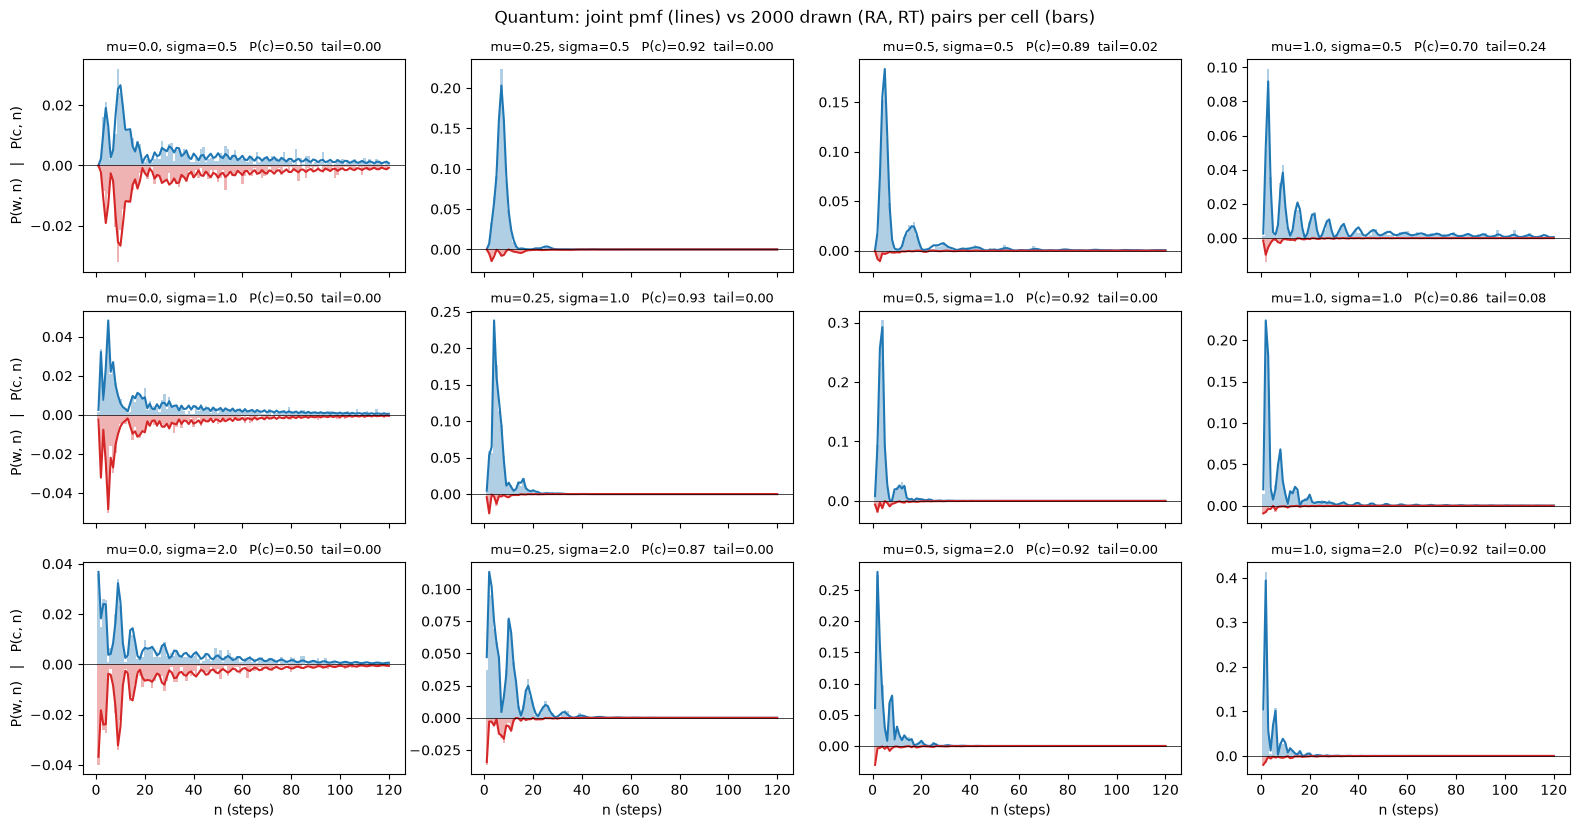

In [5]:
plot_pmf_and_samples("Quantum");

## Summary of the draws against the model

`P(c) model` is the pmf summed over $n$ and normalised by the responded mass; `P(c) sampled` is the fraction of drawn responses that are correct among responded trials. `censored` is the fraction of draws that had not responded by $n_{max}$, which should match `tail mass`.

In [6]:
def summarise(model_type):
    out = results[model_type]
    df = out["Samples"].reset_index()
    pmf = out["pmf"]
    responded = df.dropna(subset=["RA"])
    s = pd.DataFrame({
        "mu": grid["mu"].values,
        "sigma": grid["sigma"].values,
        "P(c) model": pmf[:, 0].sum(-1) / pmf.sum((-2, -1)),
        "P(c) sampled": responded.groupby("part_id").RA.apply(lambda r: (r == 1).mean()).values,
        "mean RT | c": responded[responded.RA == 1].groupby("part_id").RT.mean().values,
        "mean RT | w": responded[responded.RA == -1].groupby("part_id").RT.mean().reindex(range(I)).values,
        "censored": df.groupby("part_id").RA.apply(lambda r: r.isna().mean()).values,
        "tail mass": out["tail_mass"],
    })
    return s.round(3)

summarise("Markov")

,mu,sigma,P(c) model,P(c) sampled,mean RT | c,mean RT | w,censored,tail mass
0,0.00,0.5,0.500,0.503,55.757,56.188,0.0,0.0
1,0.25,0.5,0.965,0.964,21.995,18.155,0.0,0.0
2,0.50,0.5,0.993,0.994,12.970,7.909,0.0,0.0
3,1.00,0.5,0.999,0.998,7.630,7.333,0.0,0.0
4,0.00,1.0,0.500,0.490,32.858,32.448,0.0,0.0
5,0.25,1.0,0.896,0.894,21.194,18.977,0.0,0.0
6,0.50,1.0,0.973,0.969,13.627,10.484,0.0,0.0
7,1.00,1.0,0.995,0.994,8.249,2.917,0.0,0.0
8,0.00,2.0,0.500,0.497,22.278,21.042,0.0,0.0
9,0.25,2.0,0.791,0.786,19.760,15.803,0.0,0.0


In [7]:
summarise("Quantum")

,mu,sigma,P(c) model,P(c) sampled,mean RT | c,mean RT | w,censored,tail mass
0,0.00,0.5,0.500,0.502,52.781,54.123,0.000,0.000
1,0.25,0.5,0.917,0.924,7.325,12.569,0.000,0.000
2,0.50,0.5,0.910,0.911,22.254,87.437,0.017,0.018
3,1.00,0.5,0.922,0.916,51.006,76.492,0.242,0.245
4,0.00,1.0,0.500,0.490,33.530,33.028,0.000,0.000
5,0.25,1.0,0.928,0.924,6.453,5.882,0.000,0.000
6,0.50,1.0,0.917,0.914,5.059,9.480,0.000,0.000
7,1.00,1.0,0.937,0.936,14.568,68.254,0.082,0.079
8,0.00,2.0,0.500,0.497,32.795,30.328,0.000,0.000
9,0.25,2.0,0.871,0.870,9.546,6.912,0.000,0.000


The Quantum model at large drift relative to diffusion keeps a sizeable share of its mass unresponded: the diagonal potential of the Hamiltonian localises the amplitude away from the boundaries. The sampler reports this as censored draws instead of renormalising it away.

## Effect of `mu` and `sigma` on the response-time distributions

Histograms of the sampled response times, correct responses only, one panel per `sigma`.

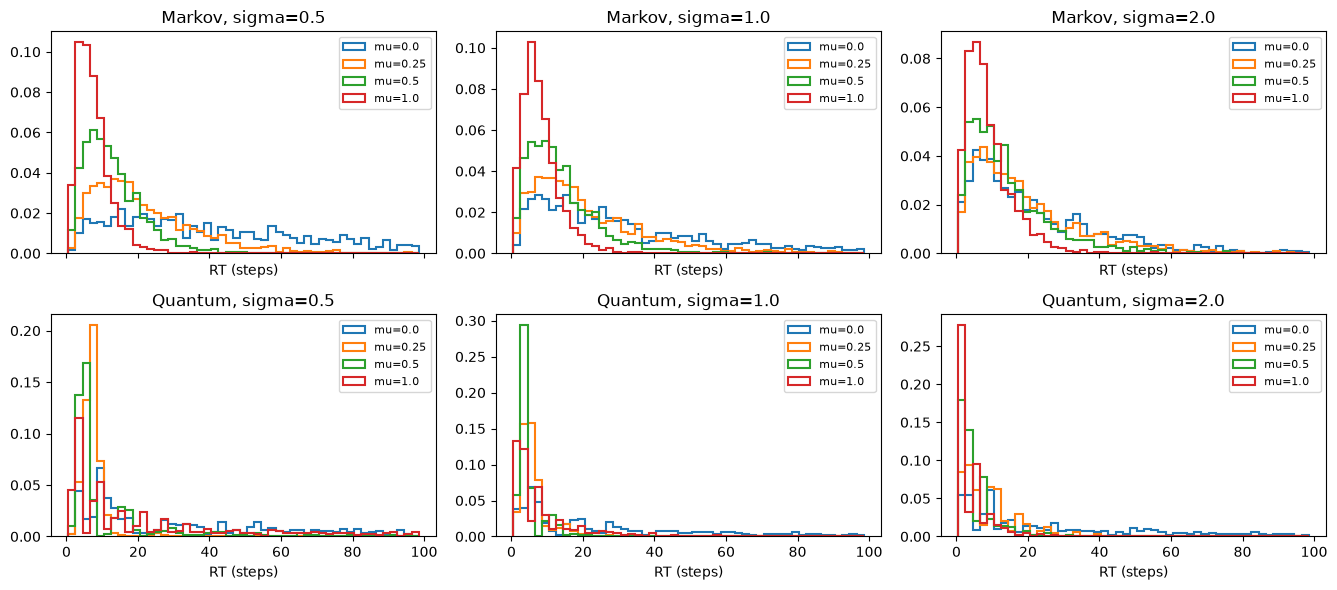

In [8]:
fig, axes = plt.subplots(2, len(sigmas), figsize=(4.5 * len(sigmas), 6), sharex="col")
for r, model_type in enumerate(["Markov", "Quantum"]):
    df = results[model_type]["Samples"].reset_index()
    for c, sigma in enumerate(sigmas):
        ax = axes[r, c]
        for i, (mu, s) in enumerate(grid.itertuples(index=False)):
            if s != sigma:
                continue
            d = df[(df.part_id == i) & (df.RA == 1)].RT
            ax.hist(d, bins=np.arange(0.5, 100.5, 2), density=True, histtype="step", lw=1.5, label=f"mu={mu}")
        ax.set_title(f"{model_type}, sigma={sigma}")
        ax.set_xlabel("RT (steps)")
        ax.legend(fontsize=8)
fig.tight_layout()

## Use through the predictive wrappers

`sample_post_pred_params` and `sample_prior_pred_params` accept `sampling_type="JOINT"` and return the same list-of-dicts structure as the `GEN` path, so `fit_model` can concatenate `samples["Samples"]` and reshape `samples["Samples"]["RT"]` as before. Below, three pseudo posterior draws for four participants.

In [9]:
rng = np.random.default_rng(1)
I_p, J_p, n_draws = 4, 50, 3
mu_draws = npx.asarray(rng.normal(0.4, 0.1, size=(n_draws, I_p, 1)))
sigma_draws = npx.asarray(rng.normal(1.0, 0.05, size=(n_draws, I_p, 1)))
phi_draws = npx.stack([ca._get_initial_state(n_states, start_width, response_width, I=I_p, model_type="Markov", prior_type="Centered")] * n_draws)
X = np.ones((I_p, J_p))

post_pd = ca.sample_post_pred_params(n_states=n_states, response_width=response_width, delta=delta, measurement_prob=measurement_prob,
                                     X=X, drift_rate_samples=mu_draws, diffusion_rate_samples=sigma_draws, phi_0_samples=phi_draws,
                                     data_samples=(I_p, J_p), max_RT_sec=30, model_type="Markov", transition_type="TIMESTEP",
                                     likelihood_type="SINGLE", sampling_type="JOINT", is_parallel=False)
df_all = pd.concat([s["Samples"] for s in post_pd])
pp_rt = np.array([s["Samples"]["RT"].values for s in post_pd]).reshape((-1, I_p, J_p))
print(pp_rt.shape)
df_all.groupby(["param_sample_id", "part_id"]).agg(acc=("RA", lambda r: (r == 1).mean()), mean_RT=("RT", "mean")).round(2)

(3, 4, 50)


acc  mean_RT
param_sample_id part_id               
0               0        0.98    13.86
                1        1.00    12.64
                2        1.00    16.60
                3        0.98    22.60
1               0        1.00    14.92
                1        1.00    13.12
                2        1.00    15.52
                3        0.98    13.38
2               0        1.00    15.64
                1        0.98    14.38
                2        0.98    14.58
                3        1.00    16.60